# Cohort Analysis — Churn by Tenure Segment

## Objective
Identify which tenure cohorts have the highest churn rates
to determine when customers are most at risk of leaving.

## Questions to Answer
- Which tenure bucket churns the most?
- Is there a "danger zone" in the customer lifecycle?
- How do monthly charges differ across cohorts?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges (same as Day 1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Convert Churn to binary (1 = churned, 0 = stayed)
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print("Data loaded. Shape:", df.shape)
print("Churn rate:", df['Churn_Binary'].mean().round(2))

Data loaded. Shape: (7043, 22)
Churn rate: 0.27


In [2]:
# Create tenure cohorts (buckets)
def tenure_cohort(tenure):
    if tenure <= 12:
        return '0-12 Months'
    elif tenure <= 24:
        return '13-24 Months'
    elif tenure <= 48:
        return '25-48 Months'
    else:
        return '49+ Months'

df['Tenure_Cohort'] = df['tenure'].apply(tenure_cohort)

# Churn rate per cohort
cohort_churn = df.groupby('Tenure_Cohort')['Churn_Binary'].agg(['mean', 'count']).round(2)
cohort_churn.columns = ['Churn_Rate', 'Customer_Count']
cohort_churn = cohort_churn.sort_values('Churn_Rate', ascending=False)

print("=== Churn Rate by Tenure Cohort ===")
print(cohort_churn)

=== Churn Rate by Tenure Cohort ===
               Churn_Rate  Customer_Count
Tenure_Cohort                            
0-12 Months          0.47            2186
13-24 Months         0.29            1024
25-48 Months         0.20            1594
49+ Months           0.10            2239


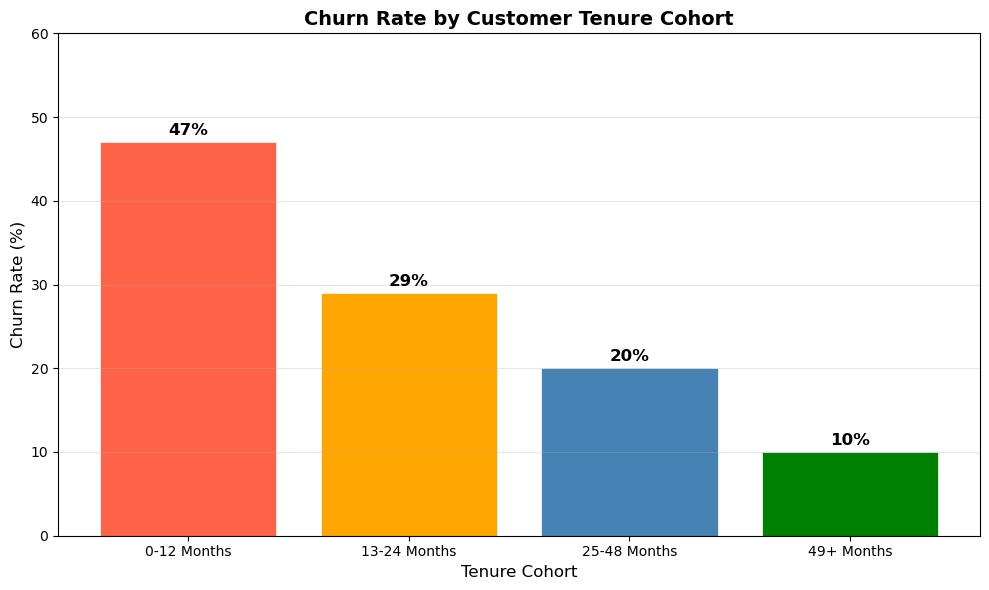


Customer count per cohort:
Tenure_Cohort
0-12 Months     2186
13-24 Months    1024
25-48 Months    1594
49+ Months      2239
Name: Customer_Count, dtype: int64


In [3]:
# Visualize cohort churn rates
cohort_order = ['0-12 Months', '13-24 Months', '25-48 Months', '49+ Months']
cohort_churn_ordered = cohort_churn.reindex(cohort_order)

colors = ['tomato', 'orange', 'steelblue', 'green']

plt.figure(figsize=(10, 6))
bars = plt.bar(cohort_churn_ordered.index, 
               cohort_churn_ordered['Churn_Rate'] * 100,
               color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, cohort_churn_ordered['Churn_Rate'] * 100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Churn Rate by Customer Tenure Cohort', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Cohort', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.ylim(0, 60)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCustomer count per cohort:")
print(cohort_churn_ordered['Customer_Count'])

## Key Finding #3 — Cohort Retention Analysis

| Tenure Cohort | Churn Rate | Customer Count |
|---|---|---|
| 0-12 Months | 47% | 2,186 |
| 13-24 Months | 29% | 1,024 |
| 25-48 Months | 20% | 1,594 |
| 49+ Months | 10% | 2,239 |

**Critical Insight:**
- 47% of new customers (0-12 months) churn — nearly 1 in 2
- Customers who survive past 12 months drop to 29% churn
- Long-term customers (49+ months) churn at only 10%
- Getting a customer past Year 1 reduces churn risk by 79%

**Business Recommendation:**
- Invest heavily in onboarding and early engagement (Month 1-3)
- Offer contract upgrade incentives at Month 6 and Month 12
- The first 12 months is the "danger zone" — this is where retention budget should focus

=== Churn Rate % by Tenure Cohort + Contract Type ===
Contract       Month-to-month  One year  Two year
Tenure_Cohort                                    
0-12 Months              51.0      10.0       0.0
13-24 Months             38.0       8.0       0.0
25-48 Months             33.0      11.0       2.0
49+ Months               26.0      13.0       3.0


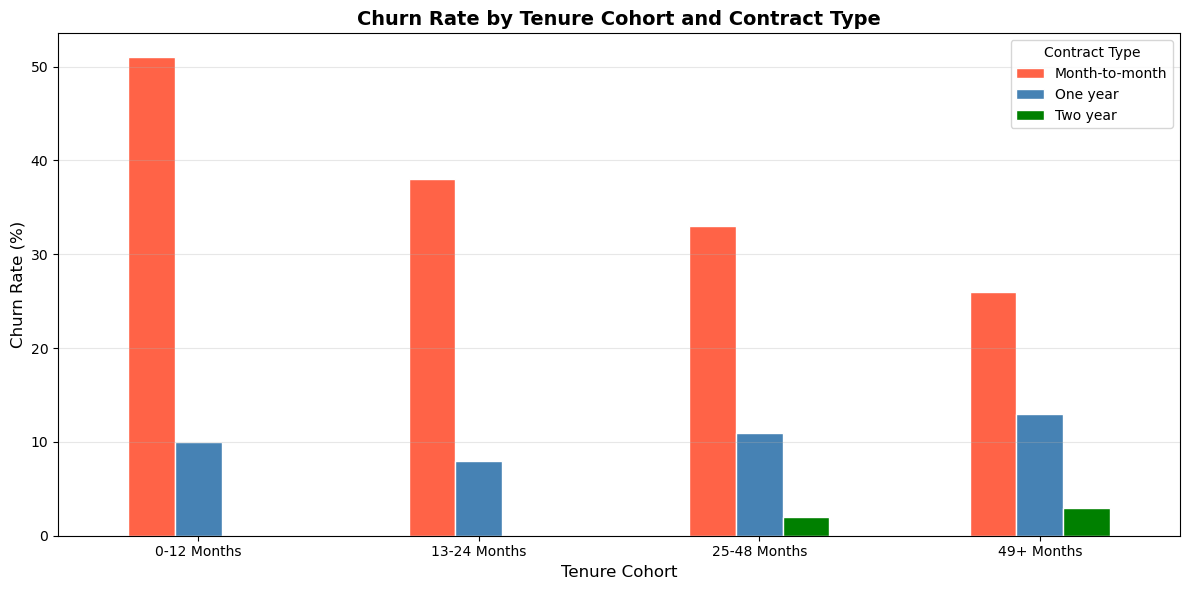

In [4]:
# Cross analysis — Contract Type within each Cohort
cross_analysis = df.groupby(['Tenure_Cohort', 'Contract'])['Churn_Binary'].mean().round(2) * 100
cross_analysis = cross_analysis.unstack()
cross_analysis = cross_analysis.reindex(cohort_order)

print("=== Churn Rate % by Tenure Cohort + Contract Type ===")
print(cross_analysis)

# Visualize
cross_analysis.plot(kind='bar', figsize=(12, 6), 
                    color=['tomato', 'steelblue', 'green'],
                    edgecolor='white')
plt.title('Churn Rate by Tenure Cohort and Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Cohort', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Contract Type')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Key Finding #4 — The Highest Risk Segment Identified

**Month-to-month + 0-12 Months = 51% churn rate**

This is the priority segment for retention intervention.

| Contract | 0-12 Months | 13-24 Months | 25-48 Months | 49+ Months |
|---|---|---|---|---|
| Month-to-month | 51% 🔴 | 38% | 33% | 26% |
| One year | 10% | 8% | 11% | 13% |
| Two year | N/A | N/A | 2% | 3% |

**Business Recommendation:**
- Target month-to-month customers at Month 3, 6, and 9 with contract upgrade offers
- A discount incentive to switch to annual contract could cut churn by ~40% in this segment
- Priority action: early onboarding program for Month 1-3 customers